This is for algorithmic experimentation for how to produce a WCS grid in ~1 ms or less.

this is the key piece that needs accelerating 
```
center_x, center_y = swcs.world_to_pixel(scoord, SpectralCoord(model_wave))
```

In [ ]:
import pickle
from pathlib import Path

import numpy as np

from matplotlib import pyplot as plt

from astropy.coordinates import SkyCoord, SpectralCoord
from astropy import units as u

from jwst import datamodels

import jax

In [ ]:
n6791fits = list(Path('../ngc6791_cals').glob('*.fits'))

dm0 = datamodels.open(n6791fits[0])

slit = dm0.slits[49]
scoord = SkyCoord(slit.source_ra, slit.source_dec, unit='deg')  # the ra and dec would have a delta in an inference loop so is different each time
swcs = slit.meta.wcs

assert slit.source_name == '2609_21'

In [11]:
with open('single_forward_model_model_spec.pkl', 'rb') as f:
    data = pickle.load(f)

model_wave = data['wave']
model_freq = model_wave.to(u.Hz, equivalencies=u.spectral())

((8945,), (8945,))

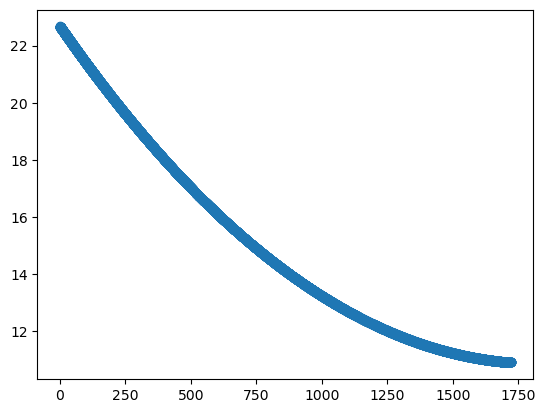

In [21]:
center_x, center_y = swcs.world_to_pixel(scoord, SpectralCoord(model_wave))
plt.scatter(center_x, center_y)
center_x.shape, center_y.shape

In [ ]:
%%timeit 

center_x, center_y = swcs.world_to_pixel(scoord, SpectralCoord(model_wave))

42.8 ms ± 1.18 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


This is the operation we need to speed up : `scoord` -> (`center_x`,`center_y`), with a constant `model_wave` .  Note we might be able to get away with a smaller model_wave, but lets target this since its the highest reasonable option.

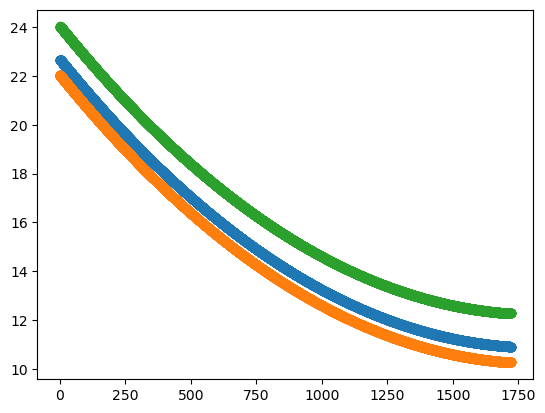

In [31]:
raoffs = [0, 0.1, -0.1]*u.arcsec
decoffs = [0, 0., 0.1]*u.arcsec
coooffs = scoord.spherical_offsets_by(raoffs, decoffs)

xs = []
ys = []
for c in coooffs:
    center_x, center_y = swcs.world_to_pixel(c, SpectralCoord(model_wave))
    xs.append(center_x)
    ys.append(center_y)
xs = np.array(xs)
ys = np.array(ys)
for x, y in zip(xs, ys):
    plt.scatter(x, y)

Actually... If the PSF can be interpolated this is unneeded - it should be in the PSF interpolation instead!  So proceed to [fast_psf.ipynb](fast_psf.ipynb)